In [1]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
# --- 1. Generate realistic time series ----------------------------------------
np.random.seed(42)
N   = 520
idx = pd.date_range("2014-01-06", periods=N, freq="W-MON")
t   = np.arange(N)

trend    = 0.18 * t
annual   = 45 * np.sin(2 * np.pi * t / 52)
biannual = 20 * np.sin(2 * np.pi * t / 26 + 0.8)
ar1      = np.zeros(N)
for i in range(1, N):
    ar1[i] = 0.72 * ar1[i - 1] + np.random.normal(0, 12)

series = pd.Series(200 + trend + annual + biannual + ar1, index=idx, name="sales")

print("=" * 64)
print("  Random Forest -- Time Series Forecasting")
print("  Signal : trend + dual seasonality + AR(1) noise")
print("=" * 64)
print(f"\n  Series : {N} weeks  ({idx[0].date()} to {idx[-1].date()})")

  Random Forest -- Time Series Forecasting
  Signal : trend + dual seasonality + AR(1) noise

  Series : 520 weeks  (2014-01-06 to 2023-12-18)


In [3]:
# --- 2. Feature engineering ---------------------------------------------------
LAGS    = [1, 2, 3, 4, 6, 8, 12, 26, 52]
WINDOWS = [4, 8, 12, 26]

def make_features(s):
    df = pd.DataFrame({"y": s})
    for lag in LAGS:
        df[f"lag_{lag}w"] = df["y"].shift(lag)
    for w in WINDOWS:
        past = df["y"].shift(1)
        df[f"rmean_{w}w"] = past.rolling(w).mean()
        df[f"rstd_{w}w"]  = past.rolling(w).std()
    df["week"]    = df.index.isocalendar().week.astype(int)
    df["month"]   = df.index.month
    df["quarter"] = df.index.quarter
    df["year_t"]  = df.index.year - df.index.year.min()
    return df.dropna()

df        = make_features(series)
feat_cols = [c for c in df.columns if c != "y"]
X, y      = df[feat_cols], df["y"]
print(f"  Features: {len(feat_cols)}")

  Features: 21


In [4]:
# --- 3. Walk-forward split ----------------------------------------------------
TEST_WEEKS = 52
split      = len(X) - TEST_WEEKS
X_tr, X_te = X.iloc[:split], X.iloc[split:]
y_tr, y_te = y.iloc[:split], y.iloc[split:]
print(f"\n  Train : {len(X_tr)} weeks  |  Test : {len(X_te)} weeks")


  Train : 416 weeks  |  Test : 52 weeks


In [5]:
# --- 4. Train -----------------------------------------------------------------
rf = RandomForestRegressor(
    n_estimators=400, max_depth=12, min_samples_leaf=4,
    max_features=0.55, bootstrap=True, oob_score=True,
    random_state=42, n_jobs=-1)
rf.fit(X_tr, y_tr)

,n_estimators,400
,criterion,'squared_error'
,max_depth,12
,min_samples_split,2
,min_samples_leaf,4
,min_weight_fraction_leaf,0.0
,max_features,0.55
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,True


In [6]:
# --- 5. Evaluate --------------------------------------------------------------
y_pred_tr = rf.predict(X_tr)
y_pred_te = rf.predict(X_te)

def show_metrics(yt, yp, tag):
    mae  = mean_absolute_error(yt, yp)
    rmse = mean_squared_error(yt, yp) ** 0.5
    r2   = r2_score(yt, yp)
    print(f"  [{tag}]  MAE={mae:.1f}  RMSE={rmse:.1f}  R2={r2:.4f}")
    return dict(mae=mae, rmse=rmse, r2=r2)

print()
m_tr = show_metrics(y_tr, y_pred_tr, "Train")
m_te = show_metrics(y_te, y_pred_te, "Test ")


  [Train]  MAE=6.2  RMSE=7.8  R2=0.9705
  [Test ]  MAE=11.5  RMSE=14.7  R2=0.8731


In [7]:
# --- 6. Uncertainty via per-tree predictions ----------------------------------
tree_preds = np.array([t.predict(X_te.values) for t in rf.estimators_])
p10 = np.percentile(tree_preds, 10, axis=0)
p90 = np.percentile(tree_preds, 90, axis=0)

In [8]:
# --- 7. Recursive multi-step future forecast ----------------------------------
FUTURE = 26

def recursive_forecast(model, history, steps):
    ext   = history.copy()
    dates = pd.date_range(history.index[-1] + pd.offsets.Week(weekday=0),
                          periods=steps + 1, freq="W-MON")[1:]
    preds = []
    for d in dates:
        tmp     = pd.concat([ext, pd.Series([np.nan], index=[d])])
        feat_df = make_features(tmp)
        if d not in feat_df.index:
            preds.append(np.nan); ext[d] = np.nan; continue
        pred = model.predict(feat_df.loc[[d], feat_cols])[0]
        preds.append(pred)
        ext[d] = pred
    return pd.Series(preds, index=dates, name="forecast")

future = recursive_forecast(rf, series, FUTURE)
print(f"\n  Future +{FUTURE}w: {future.index[0].date()} to {future.index[-1].date()}")


  Future +26w: 2024-01-01 to 2024-06-24


In [9]:
# --- 8. Feature importance ----------------------------------------------------
imp     = pd.Series(rf.feature_importances_, index=feat_cols).sort_values(ascending=False)
top_imp = imp.head(15)

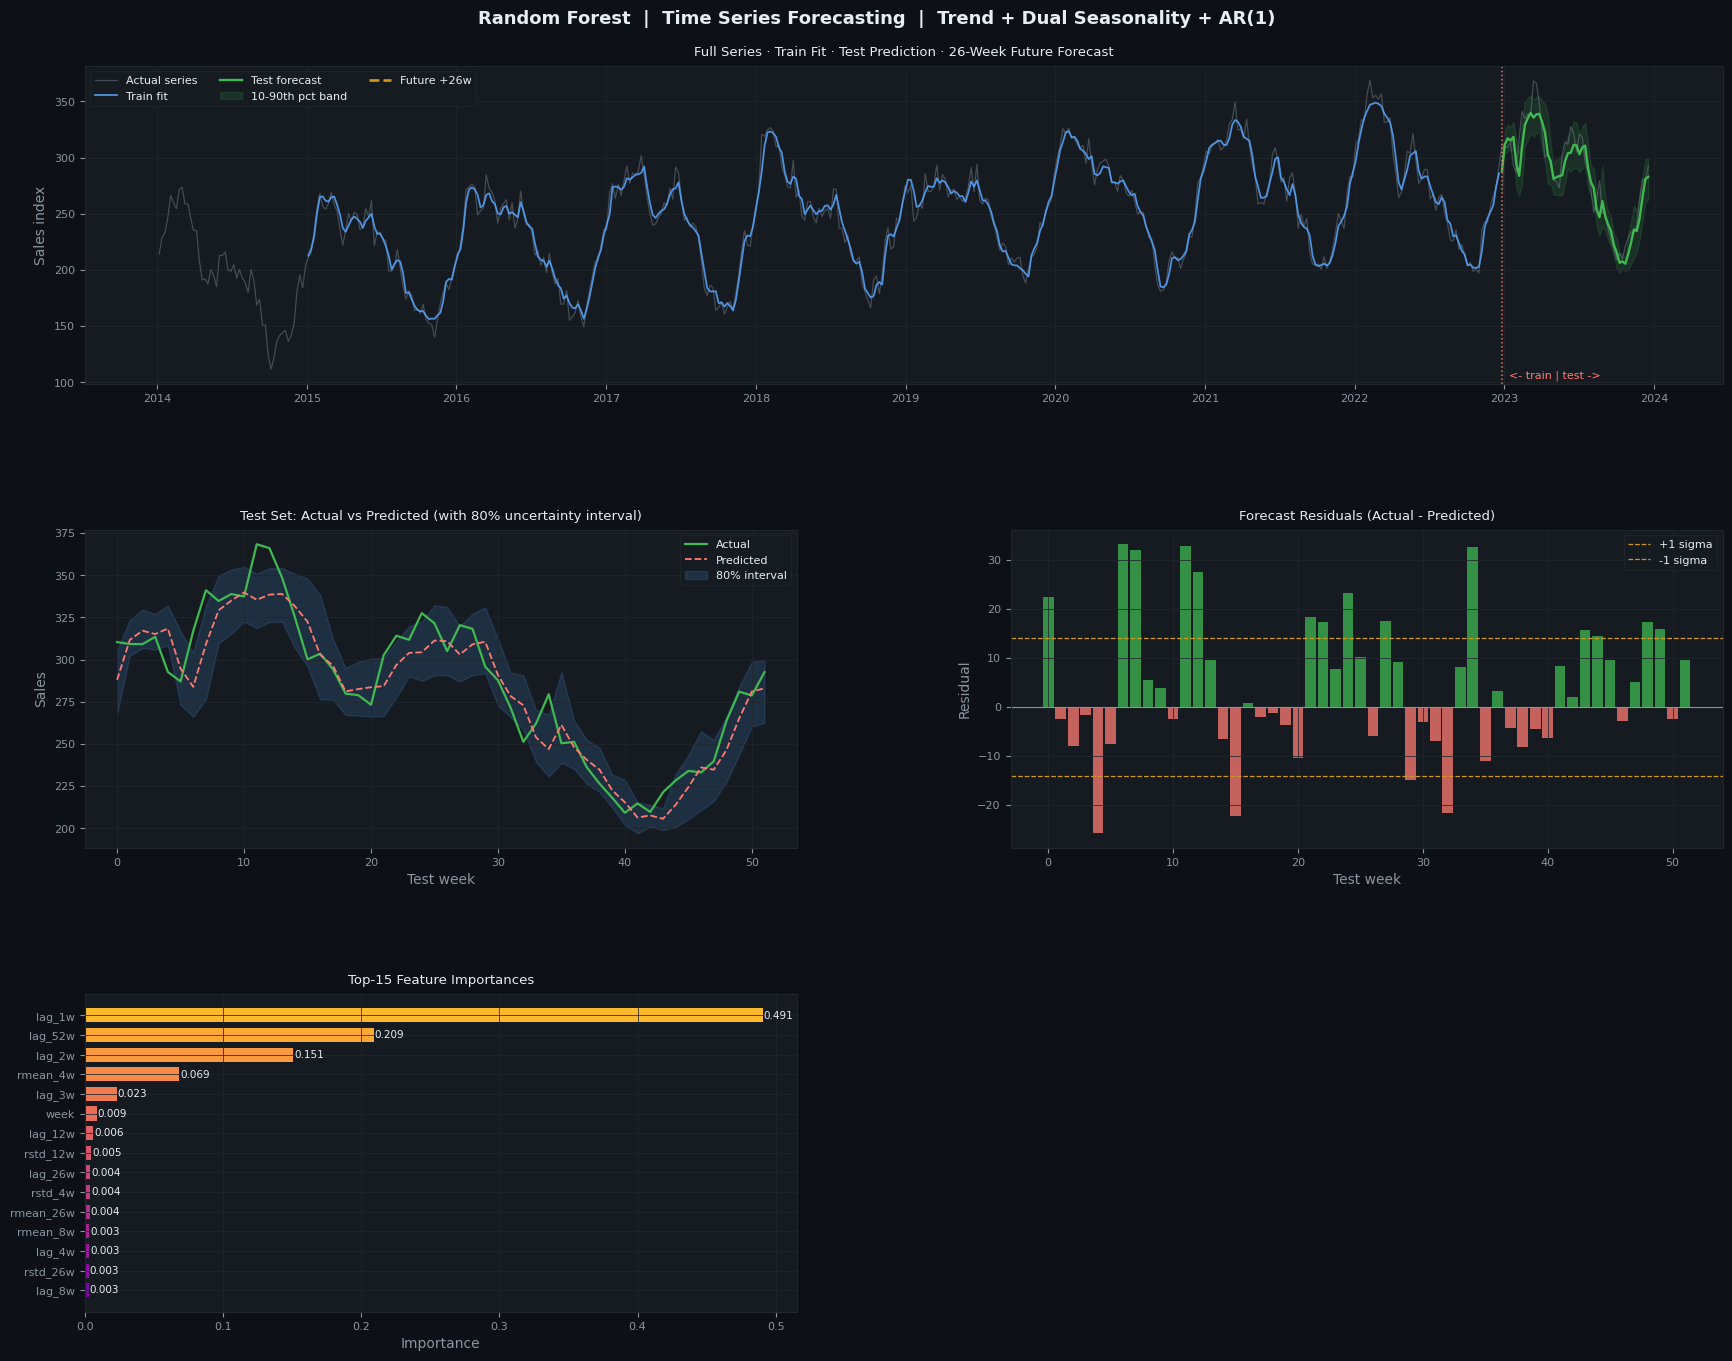

In [10]:
# --- 9. Plot ------------------------------------------------------------------
BG   = "#0d1117"; BG2 = "#161b22"; LINE = "#21262d"
BLUE = "#58a6ff"; ORG = "#ff7b72"; GRN = "#3fb950"; YLW = "#d29922"
TXT  = "#e6edf3"; STXT = "#8b949e"

fig = plt.figure(figsize=(18, 14), facecolor=BG)
gs  = gridspec.GridSpec(3, 2, figure=fig,
                        hspace=0.46, wspace=0.30,
                        top=0.94, bottom=0.05, left=0.06, right=0.97)
fig.suptitle("Random Forest  |  Time Series Forecasting  |  Trend + Dual Seasonality + AR(1)",
             fontsize=13, color=TXT, fontweight="bold")

def sax(ax, title=""):
    ax.set_facecolor(BG2)
    if title: ax.set_title(title, color=TXT, fontsize=9.5, pad=7)
    ax.tick_params(colors=STXT, labelsize=8)
    for sp in ax.spines.values(): sp.set_edgecolor(LINE)
    ax.xaxis.label.set_color(STXT); ax.yaxis.label.set_color(STXT)
    ax.grid(color=LINE, linewidth=0.7, alpha=0.8)

ax1 = fig.add_subplot(gs[0, :])
ax1.plot(series, color=STXT, lw=0.9, alpha=0.4, label="Actual series")
ax1.plot(X_tr.index, y_pred_tr, color=BLUE, lw=1.3, alpha=0.85, label="Train fit")
ax1.plot(X_te.index, y_pred_te, color=GRN,  lw=1.7, label="Test forecast")
ax1.fill_between(X_te.index, p10, p90, color=GRN, alpha=0.14, label="10-90th pct band")
ax1.plot(future.index, future.values, color=YLW, lw=1.9, ls="--", label=f"Future +{FUTURE}w")
ax1.fill_between(future.index, future.values * 0.92, future.values * 1.08,
                 color=YLW, alpha=0.10)
ax1.axvline(X_te.index[0], color=ORG, lw=1.1, ls=":", alpha=0.9)
ylims = ax1.get_ylim()
ax1.text(X_te.index[0], ylims[0] + 5, "  <- train | test ->", color=ORG, fontsize=8)
ax1.legend(fontsize=8, labelcolor=TXT, facecolor=BG2, edgecolor=LINE, ncol=3)
ax1.set_ylabel("Sales index")
sax(ax1, "Full Series · Train Fit · Test Prediction · 26-Week Future Forecast")

ax2 = fig.add_subplot(gs[1, 0])
ax2.plot(y_te.values, color=GRN, lw=1.6, label="Actual")
ax2.plot(y_pred_te,   color=ORG, lw=1.3, ls="--", label="Predicted")
ax2.fill_between(range(len(y_te)), p10, p90, color=BLUE, alpha=0.15, label="80% interval")
ax2.legend(fontsize=8, labelcolor=TXT, facecolor=BG2, edgecolor=LINE)
ax2.set_xlabel("Test week"); ax2.set_ylabel("Sales")
sax(ax2, "Test Set: Actual vs Predicted (with 80% uncertainty interval)")

ax3 = fig.add_subplot(gs[1, 1])
resid    = y_te.values - y_pred_te
colors_r = [GRN if r >= 0 else ORG for r in resid]
ax3.bar(range(len(resid)), resid, color=colors_r, width=0.85, alpha=0.75)
ax3.axhline(0,            color=STXT, lw=0.8)
ax3.axhline( resid.std(), color=YLW,  lw=0.9, ls="--", label="+1 sigma")
ax3.axhline(-resid.std(), color=YLW,  lw=0.9, ls="--", label="-1 sigma")
ax3.legend(fontsize=8, labelcolor=TXT, facecolor=BG2, edgecolor=LINE)
ax3.set_xlabel("Test week"); ax3.set_ylabel("Residual")
sax(ax3, "Forecast Residuals (Actual - Predicted)")

ax4 = fig.add_subplot(gs[2, 0])
pal  = plt.cm.plasma(np.linspace(0.25, 0.85, 15))
bars = ax4.barh(top_imp.index[::-1], top_imp.values[::-1], color=pal, height=0.72)
for bar, v in zip(bars, top_imp.values[::-1]):
    ax4.text(v + 0.0005, bar.get_y() + bar.get_height() / 2,
             f"{v:.3f}", va="center", color=TXT, fontsize=7.5)
ax4.set_xlabel("Importance")
sax(ax4, "Top-15 Feature Importances")